# Confidence intervals for cell-line recommendations (v2 — re-synced to the current pipeline)

For a queried gene, the scoring stage gives every cell line a single `core_score` in $[0,1]$. This
notebook attaches to each line a **confidence interval** on that score and two **rank-stability**
numbers (how often it lands in the top-10, and how often it is the single best), by perturbing the
scoring inputs by their measured uncertainty and recomputing the score many times.

**This version is re-synced to the rewritten `core_score.py`.** The scoring chain changed in four ways
that this notebook now mirrors exactly:

1. **RNA** is standardised per `(gene, n_sources)` and winsorised at ±5 — no longer a within-tissue
   percentile.
2. **RNA-only lines** are down-weighted by `W_RNA/W_NORM` before Φ (the "C7" fix).
3. A **regime-3 substitution**: for two-layer lines where RNA and protein are both strong and point
   opposite ways, the score uses a direct average instead of the residual.
4. **`beta_g` and the protein-residual SD are shrunk**, and both arms are winsorised at ±5.

Because the RNA percentile is gone from the *score value*, Monte-Carlo is now justified by (i) the
**rank-stability outputs**, which are counting quantities no closed form provides, and (ii) the
**regime-3 threshold and the ±5 winsor clips**, which are non-smooth — not by an RNA rank transform.

## Before you run this

Run the pipeline through Stage 4 so these exist in `final_pipeline/outputs/`: `bulk_rna_z.parquet`,
`bulk_prot_z.parquet`, `protein_platform_tier.parquet`, `core_score.parquet`, and a small
`ci_globals.json` (three panel-wide scalars — see the one-time patch below). The point score is read
from `core_score.parquet`; every per-gene standardisation constant is recomputed from the gene's own
rows using the *same code* as `core_score.py`, so the un-perturbed centre reproduces the pipeline
exactly.

## Setup and constants (mirror `core_score.py`)

In [1]:
import sys
from pathlib import Path
PIPELINE_ROOT = Path("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/final_pipeline").resolve()      # <-- set this
for p in (PIPELINE_ROOT, PIPELINE_ROOT/"utils", PIPELINE_ROOT/"02_Proteinomics", PIPELINE_ROOT/"Scoring"):
    if str(p) not in sys.path: sys.path.insert(0, str(p))

import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- scoring constants: must equal core_score.py ---
W_RNA, W_PROT = np.sqrt(1.431), np.sqrt(1.45)
W_NORM = np.sqrt(W_RNA**2 + W_PROT**2)
RHO_PRIOR, N_MIN_RHO, K_RHO, SD_SHRINK_N0 = 0.353, 30, 30, 25
RNA_STRATUM_MIN_N, RNA_STRATUM_N0, RNA_WINSOR_BOUND = 5, 25, 5.0
PROT_RESID_N0, PROT_RESID_WINSOR_BOUND = 25, 5.0
REGIME3_SIG_THRESH = 1.0
PROT_STD_STRATUM_MIN_N, PROT_STD_STRATUM_N0, PROT_STD_WINSOR_BOUND = 5, 25, 5.0

# --- noise knobs: the only new parameters (unchanged from v1) ---
RNA_BASE_FLOOR, RNA_TAU_PRIOR, COVERAGE_CAP = 0.30, 0.25, 1.5
PROT_BASE, PROT_TAU_PRIOR = 0.30, 0.45
PROT_TIER_MULT = {"consistent": 1.0, "cautious": 1.5, "conflicting": 2.2}
RNA_SOURCES_TOTAL = 3

## One-time pipeline patch — persist three global scalars

The per-gene constants are recomputable from one gene's rows, **except** three panel-wide scalars used
by `core_score.py`: the global RNA SD and protein SD (feeding `beta_g`'s shrinkage) and the global
protein-residual SD (feeding the residual-SD shrinkage). Add these lines to `core_score.py`'s `run()`,
right after `prot_resid_wide` is built and `_sd_rna_global`/`_sd_prot_global` are computed:

```python
import json
_ci_globals = {
    "sd_rna_global":  float(_sd_rna_global),
    "sd_prot_global": float(_sd_prot_global),
    "prot_resid_sd_global": float(prot_resid_wide.stack().std(ddof=1)),
}
(CORE_SCORE.parent / "ci_globals.json").write_text(json.dumps(_ci_globals))
```

That is the only change to the pipeline. Everything else this notebook needs is derived from the
stored parquets.

## Anchor — per-gene constants, recomputed exactly as the pipeline does

In [2]:
def _stratum_constants(long_df, value_col, nsrc_col, n0, min_n):
    med_g = long_df[value_col].median(); sd_g = long_df[value_col].std(ddof=1)
    sd_g  = 1e-6 if not np.isfinite(sd_g) else max(sd_g, 1e-6)
    if not np.isfinite(med_g): med_g = 0.0
    out = {}
    for nsrc, sub in long_df.groupby(nsrc_col):
        n = len(sub); med = sub[value_col].median(); sd = sub[value_col].std(ddof=1)
        sd  = sd_g if not np.isfinite(sd) else max(sd, 1e-6)
        med = med if np.isfinite(med) else med_g
        w = n/(n+n0); thin = n < min_n
        blended = w*sd**2 + (1-w)*sd_g**2
        out[int(nsrc)] = (float(w*med+(1-w)*med_g) if thin else float(med),
                          float(np.sqrt(blended)) if thin else float(sd))
    return out


def build_anchor(rna_df, prot_df, g):
    G_RNA, G_PROT, G_RESID = g["sd_rna_global"], g["sd_prot_global"], g["prot_resid_sd_global"]
    rna_str = _stratum_constants(rna_df, "rna_z", "n_sources", RNA_STRATUM_N0, RNA_STRATUM_MIN_N)
    protstd_str = (_stratum_constants(prot_df, "prot_z", "n_sources",
                   PROT_STD_STRATUM_N0, PROT_STD_STRATUM_MIN_N) if len(prot_df) else {})
    shared = prot_df.merge(rna_df[["model_id", "rna_z"]], on="model_id", how="inner")
    if len(shared) >= N_MIN_RHO:
        rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
        n = len(shared); lam = K_RHO/(n+K_RHO); rho_g = lam*RHO_PRIOR + (1-lam)*rho_raw
        w_sd = n/(n+SD_SHRINK_N0)
        sd_rna  = np.sqrt(w_sd*shared.rna_z.std(ddof=1)**2  + (1-w_sd)*G_RNA**2)
        sd_prot = np.sqrt(w_sd*shared.prot_z.std(ddof=1)**2 + (1-w_sd)*G_PROT**2)
        beta_g  = rho_g*(sd_prot/sd_rna) if sd_rna > 0 else rho_g
    else:
        beta_g = RHO_PRIOR*(G_PROT/G_RNA) if G_RNA > 0 else RHO_PRIOR
    if len(shared):
        resid = shared.prot_z - beta_g*shared.rna_z; n = len(shared)
        sd_g = max(resid.std(ddof=1), 1e-6); w = n/(n+PROT_RESID_N0)
        resid_med, resid_sd = float(resid.median()), float(np.sqrt(w*sd_g**2 + (1-w)*G_RESID**2))
    else:
        beta_g, resid_med, resid_sd = 0.0, 0.0, 1.0
    return {"rna_str": rna_str, "protstd_str": protstd_str,
            "beta_g": float(beta_g), "resid_med": resid_med, "resid_sd": resid_sd}

## The scoring chain — perturb the leaves, recompute the new `core_score`

In [3]:
def _lookup(nsrc, strata, default=(0.0, 1.0)):
    med = np.array([strata.get(int(k), default)[0] if np.isfinite(k) else default[0] for k in nsrc])
    sd  = np.array([strata.get(int(k), default)[1] if np.isfinite(k) else default[1] for k in nsrc])
    return med, sd


def core_score_chain(rna_z, prot_z, nsrc_rna, nsrc_prot, has_p, a):
    rmed, rsd = _lookup(nsrc_rna, a["rna_str"])
    rna_std_z = np.clip((rna_z - rmed)/rsd, -RNA_WINSOR_BOUND, RNA_WINSOR_BOUND)
    core_z = np.where(has_p, np.nan, (W_RNA/W_NORM)*rna_std_z)          # 1-layer (C7 down-weight)
    if has_p.any():
        pmed, psd = _lookup(np.where(has_p, nsrc_prot, np.nan), a["protstd_str"])
        with np.errstate(invalid="ignore"):
            prot_std_z = np.clip((prot_z - pmed)/psd, -PROT_STD_WINSOR_BOUND, PROT_STD_WINSOR_BOUND)
            prot_resid = prot_z - a["beta_g"]*rna_z
            prot_resid_z = np.clip((prot_resid - a["resid_med"])/a["resid_sd"],
                                   -PROT_RESID_WINSOR_BOUND, PROT_RESID_WINSOR_BOUND)
            core_z_A = (W_RNA*rna_std_z + W_PROT*prot_resid_z)/W_NORM
            core_z_C = (W_RNA*rna_std_z + W_PROT*np.nan_to_num(prot_std_z))/W_NORM
            reg3 = ((np.abs(rna_std_z) > REGIME3_SIG_THRESH) & (np.abs(prot_std_z) > REGIME3_SIG_THRESH)
                    & (np.sign(rna_std_z) != np.sign(prot_std_z)) & np.isfinite(prot_std_z))
        core_z = np.where(has_p, np.where(reg3, core_z_C, core_z_A), core_z)
    return stats.norm.cdf(core_z)

## Monte-Carlo — interval + rank-stability

In [4]:
def monte_carlo_ci(base, anchor, N=1000, k=10, seed=42, ci=0.95):
    rng = np.random.default_rng(seed)
    ids = base.model_id.to_numpy(); n = len(base); lineage = base.lineage.to_numpy()
    rna_mu, rna_sd = base.rna_z.to_numpy(), base.se_rna.to_numpy()
    nsrc_rna = base.n_sources_rna.to_numpy(float)
    has_p = base.prot_z.notna().to_numpy()
    prot_mu = base.prot_z.to_numpy(float); prot_sd = np.nan_to_num(base.se_prot.to_numpy(float))
    nsrc_prot = base.n_sources_prot.to_numpy(float)
    score = lambda rz, pz: core_score_chain(rz, pz, nsrc_rna, nsrc_prot, has_p, anchor)

    centre = score(rna_mu, prot_mu)
    scores = np.empty((N, n)); top_g = np.zeros(n); top_l = np.zeros(n); win1 = np.zeros(n)
    for i in range(N):
        rz = rna_mu + rng.normal(0, 1, n)*rna_sd
        pz = prot_mu.copy(); pz[has_p] = prot_mu[has_p] + rng.normal(0, 1, int(has_p.sum()))*prot_sd[has_p]
        s = score(rz, pz); scores[i] = s
        o = np.argsort(-s); top_g[o[:k]] += 1; win1[o[0]] += 1
        t = pd.DataFrame({"s": s, "lin": lineage})
        t["r"] = t.groupby("lin")["s"].rank(ascending=False, method="first")
        top_l[(t["r"] <= k).to_numpy()] += 1
    lo, hi = (1-ci)/2, 1-(1-ci)/2
    out = pd.DataFrame({"model_id": ids, "lineage": lineage, "core_score": centre,
        "ci_lo": np.quantile(scores, lo, axis=0), "ci_hi": np.quantile(scores, hi, axis=0),
        "topk_global_pct": 100*top_g/N, "topk_lineage_pct": 100*top_l/N, "top1_winrate": 100*win1/N,
        "n_layers": np.where(has_p, 2, 1), "n_sources": base.n_sources_rna.to_numpy()})
    out["ci_lo"] = np.minimum(out.ci_lo, out.core_score); out["ci_hi"] = np.maximum(out.ci_hi, out.core_score)
    out["ci_width"] = out.ci_hi - out.ci_lo
    return out.sort_values("core_score", ascending=False).reset_index(drop=True), scores, ids

## Real-database wiring

In [15]:
def _resolve_gid(con, gene):
    g = str(gene).strip()
    if g.upper().startswith("ENSG"): return g.upper()
    r = con.execute("SELECT gene_id FROM gene WHERE lower(hugo_symbol)=lower(?) LIMIT 1", [g]).fetchone()
    if not r: raise ValueError(f"gene not found: {gene}")
    return r[0].upper()


def _rna_per_source(con, gid):
    import common as C
    gid = gid.lower(); lm = C.load_lineage(con)
    wide = lambda l: l.pivot_table(index="model_id", columns="gene_id", values="value", aggfunc="median")
    frames = []
    for fetch, name in [(C.fetch_depmap,"depmap_expr"),(C.fetch_geo,"geo_expr"),(C.fetch_hpa,"hpa_rna")]:
        l = fetch(con, [gid])
        if len(l): frames.append(C.score_source_lineage(wide(l), [gid], lm, name))
    if not frames: return pd.DataFrame(columns=["model_id","source","z"])
    return pd.concat(frames, ignore_index=True)[["model_id","source","z"]].dropna()


def _gene_leaves(con, gene):
    import protein_scorer as PS
    from config import RNA_Z, PROT_Z, PROT_TIER
    gid = _resolve_gid(con, gene).upper()
    rz = pd.read_parquet(RNA_Z).rename(columns={"z_t":"rna_z", "k_src":"n_sources"})
    rz["gene_id"] = rz.gene_id.str.upper()
    rz = rz[rz.gene_id==gid][["model_id","rna_z","n_sources"]].copy(); rz["model_id"]=rz.model_id.str.lower()
    pz = pd.read_parquet(PROT_Z).rename(columns={"z_t":"prot_z"}); pz["gene_id"]=pz.gene_id.str.upper()
    pz = pz[pz.gene_id==gid][["model_id","prot_z","n_sources"]].copy(); pz["model_id"]=pz.model_id.str.lower()

    # RNA se: between-source disagreement + coverage floor
    # per = _rna_per_source(con, gid)
    # if len(per):
    #     per["model_id"] = per.model_id.str.lower()
    #     disp = per.groupby("model_id")["z"].agg(s_between="std", k="count")
    #     rz = rz.merge(disp, on="model_id", how="left")
    # else:
    #     rz["s_between"] = np.nan

    # between-source RNA disagreement, read directly from the per-source export
    from config import RNA_Z
    rbs = pd.read_parquet(RNA_Z.parent / "bulk_rna_z_by_source.parquet")
    rbs["gene_id"] = rbs.gene_id.str.upper()
    rbs = rbs[rbs.gene_id == gid].copy()
    rbs["model_id"] = rbs.model_id.str.lower()
    rna_src_cols = ["z_depmap", "z_hpa_rna", "z_geo"]
    rbs["s_between"] = rbs[rna_src_cols].std(axis=1, ddof=1)     # SD across the sources that saw the line
    rz = rz.merge(rbs[["model_id", "s_between"]], on="model_id", how="left")
    
    k = rz.n_sources.to_numpy()
    se_b = np.where(k>=2, rz.s_between.to_numpy()/np.sqrt(np.maximum(k,1)), RNA_TAU_PRIOR)
    se_b = np.where(np.isfinite(se_b), se_b, RNA_TAU_PRIOR)
    se_w = RNA_BASE_FLOOR*np.minimum(np.sqrt(RNA_SOURCES_TOTAL/np.maximum(k,1)), COVERAGE_CAP)
    rz["se_rna"] = np.sqrt(se_b**2 + se_w**2)

    # protein se: platform-tier scale + measured per-line ProCAN-vs-CCLE disagreement
    u2e = PS._build_uniprot_ensg(con); uni = {u for u,e in u2e.items() if e==gid}
    tier_df = pd.read_parquet(PROT_TIER); tier_df["uniprot"]=tier_df.uniprot.str.lower()
    trow = tier_df[tier_df.uniprot.isin(uni)]
    tier = str(trow.sort_values("platform_rho").iloc[0].platform_tier) if len(trow) else "cautious"
    mult = PROT_TIER_MULT.get(tier, 1.5)

    # per-line disagreement from the per-source export (NaN when only one platform)
    from config import PROT_Z
    pbs = pd.read_parquet(PROT_Z.parent / "bulk_prot_z_by_source.parquet")
    pbs["gene_id"] = pbs.gene_id.str.upper()
    pbs = pbs[pbs.gene_id == gid].copy()
    pbs["model_id"] = pbs.model_id.str.lower()
    pbs["p_between"] = pbs[["z_procan", "z_ccle"]].std(axis=1, ddof=1) / np.sqrt(2)
    pz = pz.merge(pbs[["model_id", "p_between"]], on="model_id", how="left")

    tier_floor = mult * PROT_BASE
    p_between  = pz["p_between"].to_numpy()
    one_plat   = pz.n_sources.to_numpy() < 2
    se_meas    = np.sqrt(np.nan_to_num(p_between)**2 + tier_floor**2)   # both platforms: measured + floor
    se_prior   = np.sqrt(tier_floor**2 + PROT_TAU_PRIOR**2)             # one platform: tier + prior
    pz["se_prot"] = np.where(one_plat | ~np.isfinite(p_between), se_prior, se_meas)
    return rz, pz, gid


def run_gene_ci(con, gene, N=1000, k=10, seed=42):
    import json
    from config import CORE_SCORE
    rz, pz, gid = _gene_leaves(con, gene)
    g_globals = json.loads((CORE_SCORE.parent/"ci_globals.json").read_text())
    anchor = build_anchor(rz.rename(columns={"n_sources":"n_sources"}),
                          pz.rename(columns={"n_sources":"n_sources"}), g_globals)
    import common as C
    lm = C.load_lineage(con); lm.index = lm.index.str.lower()
    base = (rz.rename(columns={"n_sources":"n_sources_rna"})
              .merge(pz.rename(columns={"n_sources":"n_sources_prot"}), on="model_id", how="left"))
    base["lineage"] = base.model_id.map(lm)
    return monte_carlo_ci(base, anchor, N=N, k=k, seed=seed)

# import duckdb; from config import DB
# con = duckdb.connect(str(DB), read_only=True)
# res, scores, ids = run_gene_ci(con, "EGFR", N=1000)

# Sanity checks

In [6]:
import duckdb, pandas as pd
from config import DB, RNA_Z, PROT_Z, PROT_TIER
from pathlib import Path

for name, p in [("celllineselector.db", DB), ("bulk_rna_z", RNA_Z),
                ("bulk_prot_z", PROT_Z), ("protein_platform_tier", PROT_TIER),
                ("bulk_rna_z_by_source", RNA_Z.parent/"bulk_rna_z_by_source.parquet"),
                ("bulk_prot_z_by_source", PROT_Z.parent/"bulk_prot_z_by_source.parquet")]:
    print(f"{name:26s} {'OK' if Path(p).exists() else 'MISSING'}")

# confirm the z-stores have the columns core_score.py + the CI need
for nm, p in [("rna", RNA_Z), ("prot", PROT_Z)]:
    print(nm, list(pd.read_parquet(p).columns))          # expect gene_id, model_id, z_t, n_sources
print("by_source rna cols:", list(pd.read_parquet(RNA_Z.parent/"bulk_rna_z_by_source.parquet").columns))

celllineselector.db        OK
bulk_rna_z                 OK
bulk_prot_z                OK
protein_platform_tier      OK
bulk_rna_z_by_source       OK
bulk_prot_z_by_source      OK
rna ['gene_id', 'model_id', 'z_t', 'k_src']
prot ['gene_id', 'model_id', 'z_t', 'n_sources']
by_source rna cols: ['gene_id', 'model_id', 'z_depmap', 'z_hpa_rna', 'z_geo']


# Run Stage 4 (regenerates core_score.parquet + ci_globals.json with patched scorer)

In [7]:
import gc, duckdb
from importlib import import_module, reload
for o in gc.get_objects():                      # release any DuckDB write-lock first
    if isinstance(o, duckdb.DuckDBPyConnection):
        try: o.close()
        except Exception: pass
cs = import_module("Scoring.core_score"); reload(cs); cs.run()

Scoring — core_score (RNA + Protein orthogonal combination)
RNA  rows: 18,696,103  |  genes: 16,992
Prot rows: 9,906,642  |  genes: 12,180
  rna_std_z SD by k_src (post-standardise, target 1.00): {1: 0.9995793757162008, 2: 0.9993790655613037, 3: 0.9984748042127388}
  prot_std_z SD by n_sources (post-standardise, target 1.00, regime-3 detection only): {1: 0.9105230296280744, 2: 0.8448769892706086}


/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/final_pipeline/Scoring/core_score.py:417: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw, _ = stats.pearsonr(grp["prot_z"].fillna(0), grp["rna_z"].fillna(0))


  prot_resid_z SD (post-standardise): mean=0.8938  (target 1.00)
Regime 3 rows substituted (direct average, opposite-sign confident disagreement): 75,117 / 9,733,776 (0.7717%)
n_layers=1 fallback (protein-free lines, C7-scaled): 742 lines, 7,192,628 pairs
RNA-only genes added (C7-scaled): 5,136

Done in 112s
core_score: 17,370,349 rows  ->  /Users/musa.official/Documents/UoB-GeneTraceAI-25-26/final_pipeline/outputs/core_score.parquet
  genes: 16,992  |  lines: 1,563
  core_score mean: 0.494
  combination_variant counts: {'A_fallback_scaled': 10607447, 'A': 6687785, 'C_regime3': 75117}


In [8]:
from config import CORE_SCORE
import pandas as pd
print("core_score:", CORE_SCORE.exists(), "| ci_globals:", (CORE_SCORE.parent/"ci_globals.json").exists())
print(pd.read_parquet(CORE_SCORE).combination_variant.value_counts().to_dict())

core_score: True | ci_globals: True
{'A_fallback_scaled': 10607447, 'A': 6687785, 'C_regime3': 75117}


# Run the CI on a real gene and the centre-draw check

In [11]:
import duckdb
from config import DB, CORE_SCORE
con = duckdb.connect(str(DB), read_only=True)
res, scores, ids = run_gene_ci(con, "EGFR", N=1000, k=10)
id_ix = {m:i for i,m in enumerate(ids)}

core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core.ensg_id.str.upper()
gid = _resolve_gid(con, "EGFR").upper()
ref = core[core.ensg_id==gid].assign(model_id=lambda d: d.model_id.str.lower())
got = res.assign(model_id=lambda d: d.model_id.str.lower())
m = got.merge(ref[["model_id","core_score"]].rename(columns={"core_score":"r"}), on="model_id")
print("compared:", len(m), "| max|Δ|:", (m.core_score - m.r).abs().max())

compared: 1336 | max|Δ|: 1.792132892086684e-08


In [12]:
core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core.ensg_id.str.upper()
for gsym in ["EGFR", "TP53", "MYC"]:
    rr, _, _ = run_gene_ci(con, gsym, N=300)
    e = core[core.ensg_id==_resolve_gid(con, gsym).upper()].assign(model_id=lambda d: d.model_id.str.lower())
    rr["model_id"] = rr.model_id.str.lower()
    mm = rr.merge(e[["model_id","core_score"]].rename(columns={"core_score":"r"}), on="model_id")
    print(f"{gsym:6s} compared={len(mm):5d}  n1={int((rr.n_layers==1).sum()):4d}  max|Δ|={(mm.core_score-mm.r).abs().max():.2e}")

EGFR   compared= 1336  n1= 642  max|Δ|=1.79e-08
TP53   compared= 1563  n1= 742  max|Δ|=4.96e-09
MYC    compared= 1103  n1=1170  max|Δ|=9.69e-09


In [13]:
import pandas as pd, numpy as np
from config import RNA_Z, PROT_Z

rna_bs = pd.read_parquet(RNA_Z.parent / "bulk_rna_z_by_source.parquet")
prot_bs = pd.read_parquet(PROT_Z.parent / "bulk_prot_z_by_source.parquet")

print("RNA by_source columns :", list(rna_bs.columns))
print("PROT by_source columns:", list(prot_bs.columns))
print("RNA rows:", f"{len(rna_bs):,}", "| PROT rows:", f"{len(prot_bs):,}")
print()

# 1) do the per-source columns look like z-scores? (roughly mean~0, sd~1, symmetric)
rna_src = [c for c in rna_bs.columns if c not in ("gene_id","model_id")]
print("RNA per-source stats:")
print(rna_bs[rna_src].describe().loc[["mean","std","min","max"]].round(2).to_string())
print("\nfraction NaN per source (single-source lines expected to have NaNs):")
print((rna_bs[rna_src].isna().mean()).round(3).to_string())

RNA by_source columns : ['gene_id', 'model_id', 'z_depmap', 'z_hpa_rna', 'z_geo']
PROT by_source columns: ['gene_id', 'model_id', 'z_procan', 'z_ccle']
RNA rows: 18,696,103 | PROT rows: 6,436,493

RNA per-source stats:
      z_depmap  z_hpa_rna  z_geo
mean     -0.02      -0.01  -0.03
std       1.03       1.02   1.08
min     -19.02     -20.82 -21.33
max      20.10      25.71  19.93

fraction NaN per source (single-source lines expected to have NaNs):
z_depmap     0.078
z_hpa_rna    0.310
z_geo        0.862


In [14]:
# 2) do the by_source model_ids and genes overlap the combined store?
rna_comb = pd.read_parquet(RNA_Z)
rna_comb.columns = [c.lower() for c in rna_comb.columns]
print("genes — combined:", rna_comb.gene_id.str.upper().nunique(),
      "| by_source:", rna_bs.gene_id.str.upper().nunique())
print("models overlap:", len(set(rna_bs.model_id.str.lower()) & set(rna_comb.model_id.str.lower())),
      "/", rna_bs.model_id.str.lower().nunique())

# 3) does the count of non-NaN sources match the combined store's k_src/n_sources?
nsrc_col = "k_src" if "k_src" in rna_comb.columns else "n_sources"
chk = rna_bs.assign(model_id=rna_bs.model_id.str.lower(), gene_id=rna_bs.gene_id.str.upper())
chk["n_nonnan"] = chk[rna_src].notna().sum(axis=1)
comb = rna_comb.assign(model_id=rna_comb.model_id.str.lower(), gene_id=rna_comb.gene_id.str.upper())
mrg = chk.merge(comb[["gene_id","model_id",nsrc_col]], on=["gene_id","model_id"], how="inner")
print("rows where non-NaN source count == combined", nsrc_col, ":",
      f"{(mrg['n_nonnan'] == mrg[nsrc_col]).mean():.1%}")

genes — combined: 16992 | by_source: 16992
models overlap: 1563 / 1563
rows where non-NaN source count == combined k_src : 100.0%


# Re-run the EGFR centre-draw check after both swaps

In [17]:
import duckdb
from config import DB, CORE_SCORE
con = duckdb.connect(str(DB), read_only=True)
res, scores, ids = run_gene_ci(con, "EGFR", N=1000, k=10)
id_ix = {m:i for i,m in enumerate(ids)}

core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core.ensg_id.str.upper()
gid = _resolve_gid(con, "EGFR").upper()
ref = core[core.ensg_id==gid].assign(model_id=lambda d: d.model_id.str.lower())
got = res.assign(model_id=lambda d: d.model_id.str.lower())
m = got.merge(ref[["model_id","core_score"]].rename(columns={"core_score":"r"}), on="model_id")
print("compared:", len(m), "| max|Δ|:", (m.core_score - m.r).abs().max())

compared: 1336 | max|Δ|: 1.792132892086684e-08


In [16]:
res2, _, _ = run_gene_ci(con, "EGFR", N=1000)
print("mean CI width by n_sources:\n", res2.groupby("n_sources").ci_width.mean().round(3).to_string())

mean CI width by n_sources:
 n_sources
1    0.431
2    0.351
3    0.379


## Quick check
Look at whether the 3-source widening concentrates on lines where GEO is present and disagrees.

In [18]:
res2, _, _ = run_gene_ci(con, "EGFR", N=1000)
rbs = pd.read_parquet(RNA_Z.parent/"bulk_rna_z_by_source.parquet")
rbs = rbs[rbs.gene_id.str.upper()==_resolve_gid(con,"EGFR").upper()].assign(model_id=lambda d:d.model_id.str.lower())
rbs["has_geo"] = rbs.z_geo.notna()
rbs["src_sd"]  = rbs[["z_depmap","z_hpa_rna","z_geo"]].std(axis=1, ddof=1)
m = res2.assign(model_id=res2.model_id.str.lower()).merge(rbs[["model_id","has_geo","src_sd"]], on="model_id", how="left")
print(m[m.n_sources==3].groupby("has_geo")[["ci_width","src_sd"]].mean().round(3))

         ci_width  src_sd
has_geo                  
True        0.379   0.367


In [19]:
print(m.groupby("n_sources")[["src_sd","ci_width"]].mean().round(3))

           src_sd  ci_width
n_sources                  
1             NaN     0.431
2           0.116     0.351
3           0.367     0.379


# Testing

In [20]:
import numpy as np, pandas as pd
from config import RNA_Z, CORE_SCORE

# --- pick a gene sample: spread across coverage, not just famous genes ---
core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core.ensg_id.str.upper()
all_genes = core.ensg_id.unique()
rng = np.random.default_rng(0)
sample = rng.choice(all_genes, size=60, replace=False)     # 60 genes; raise if you have time

# per-source RNA file, loaded once, indexed for fast per-gene slicing
rbs_all = pd.read_parquet(RNA_Z.parent / "bulk_rna_z_by_source.parquet")
rbs_all["gene_id"] = rbs_all.gene_id.str.upper()
rbs_all["model_id"] = rbs_all.model_id.str.lower()
rbs_all["src_sd"] = rbs_all[["z_depmap","z_hpa_rna","z_geo"]].std(axis=1, ddof=1)
rbs_all["has_geo"] = rbs_all.z_geo.notna()

rows = []
for gid in sample:
    try:
        res_g, _, _ = run_gene_ci(con, gid, N=300)     # smaller N: many genes, relative widths only
    except Exception:
        continue
    res_g = res_g.assign(model_id=res_g.model_id.str.lower())
    rg = rbs_all[rbs_all.gene_id == gid][["model_id","src_sd","has_geo"]]
    m = res_g.merge(rg, on="model_id", how="left")
    m["ensg_id"] = gid
    rows.append(m[["ensg_id","model_id","n_sources","ci_width","src_sd","has_geo","core_score"]])

pool = pd.concat(rows, ignore_index=True)
print(f"pooled rows: {len(pool):,} across {pool.ensg_id.nunique()} genes")

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


pooled rows: 63,040 across 60 genes


In [21]:
# 1) POOLED: does width scale with measured disagreement, controlling for count?
#    If width tracks src_sd (not count), the correlation should be positive
#    WITHIN each source-count group.
print("\ncorr(ci_width, src_sd) within each n_sources group:")
for k in (2, 3):
    sub = pool[(pool.n_sources == k) & pool.src_sd.notna()]
    if len(sub) > 30:
        print(f"  n_sources={k}: r={sub.ci_width.corr(sub.src_sd):.3f}  (n={len(sub):,})")

# 2) THE 2-vs-3 QUESTION, per gene: is 3-source wider than 2-source, and does
#    that track whether GEO adds disagreement? Compare per gene, then summarise.
g = (pool[pool.n_sources.isin([2,3])]
     .groupby(["ensg_id","n_sources"])
     .agg(width=("ci_width","mean"), sd=("src_sd","mean")).reset_index())
piv = g.pivot(index="ensg_id", columns="n_sources", values=["width","sd"]).dropna()
piv.columns = ["w2","w3","sd2","sd3"]
piv["width_3_minus_2"] = piv.w3 - piv.w2
piv["sd_3_minus_2"]    = piv.sd3 - piv.sd2
print(f"\ngenes where 3-source is WIDER than 2-source: "
      f"{(piv.width_3_minus_2 > 0).mean():.0%} of {len(piv)} genes")
print("corr(Δwidth[3-2], Δsrc_sd[3-2]) across genes:",
      round(piv.width_3_minus_2.corr(piv.sd_3_minus_2), 3))

# 3) IS IT GEO SPECIFICALLY? Within 3-source lines pooled across genes,
#    split by whether GEO is present (some genes may have 3-source lines
#    where the third source is not GEO — this tests GEO's contribution).
three = pool[(pool.n_sources == 3)]
if three.has_geo.nunique() > 1:
    print("\n3-source lines, GEO present vs absent (pooled):")
    print(three.groupby("has_geo")[["src_sd","ci_width"]].mean().round(3).to_string())
else:
    print("\n(3-source lines all have GEO in this sample — as for EGFR — "
          "so GEO-present/absent can't be contrasted; analysis 2 carries the claim)")


corr(ci_width, src_sd) within each n_sources group:
  n_sources=2: r=0.136  (n=36,345)
  n_sources=3: r=0.101  (n=5,914)

genes where 3-source is WIDER than 2-source: 76% of 45 genes
corr(Δwidth[3-2], Δsrc_sd[3-2]) across genes: -0.26

(3-source lines all have GEO in this sample — as for EGFR — so GEO-present/absent can't be contrasted; analysis 2 carries the claim)


In [22]:
# Does the 3>2 width gap survive controlling for score position?
# Bin by core_score, then compare 2- vs 3-source width within each bin.
pool["score_bin"] = pd.cut(pool.core_score, bins=[0,.2,.4,.6,.8,1.0])
tab = (pool[pool.n_sources.isin([2,3])]
       .groupby(["score_bin","n_sources"], observed=True)["ci_width"].mean().unstack())
print("mean ci_width by score bin × n_sources:")
print(tab.round(3).to_string())

# And: within fixed source count, what predicts width better — src_sd or score position?
for k in (2,3):
    sub = pool[(pool.n_sources==k) & pool.src_sd.notna()].copy()
    sub["dist_from_mid"] = (sub.core_score - 0.5).abs()      # saturation proxy
    print(f"\nn_sources={k}:  corr(width, src_sd)={sub.ci_width.corr(sub.src_sd):.3f}  "
          f"corr(width, |score-0.5|)={sub.ci_width.corr(sub.dist_from_mid):.3f}")

mean ci_width by score bin × n_sources:
n_sources       2      3
score_bin               
(0.0, 0.2]  0.301  0.324
(0.2, 0.4]  0.438  0.480
(0.4, 0.6]  0.476  0.538
(0.6, 0.8]  0.434  0.492
(0.8, 1.0]  0.283  0.328

n_sources=2:  corr(width, src_sd)=0.136  corr(width, |score-0.5|)=-0.327

n_sources=3:  corr(width, src_sd)=0.101  corr(width, |score-0.5|)=-0.325


## Centre-draw check (run on real data)

The un-perturbed centre must equal the stored `core_score`. The stored file also carries a
`combination_variant` column (`A`, `C_regime3`, `A_fallback_scaled`) — a useful cross-check that the
chain applied the right formula per row.

```python
from config import CORE_SCORE
core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core.ensg_id.str.upper()
gid = _resolve_gid(con, "EGFR").upper()
ref = core[core.ensg_id==gid].assign(model_id=lambda d: d.model_id.str.lower())
got = res.assign(model_id=lambda d: d.model_id.str.lower())
m = got.merge(ref[["model_id","core_score"]].rename(columns={"core_score":"r"}), on="model_id")
print("compared:", len(m), "| max|Δ|:", (m.core_score - m.r).abs().max())
```

## A runnable example (synthetic gene)

In [6]:
def make_demo(n=300, seed=3):
    rng = np.random.default_rng(seed)
    lines = np.array([f"ach-{i:04d}" for i in range(n)])
    lineages = np.array(["tissue_A","tissue_B","tissue_C","tissue_D","tissue_E"])
    lin = np.where(np.arange(n) % 3 == 0, "tissue_A", rng.choice(lineages, n))
    true = rng.normal(0, 1, n) + (lin == "tissue_A")*1.2
    rna = pd.DataFrame({"model_id": lines, "rna_z": true + rng.normal(0, 0.4, n),
                        "n_sources": rng.choice([1,2,3], n, p=[.15,.25,.60])})
    mask = rng.random(n) < 0.55
    prot = pd.DataFrame({"model_id": lines[mask], "prot_z": 0.55*true[mask]+rng.normal(0,0.6,mask.sum()),
                         "n_sources": rng.choice([1,2], mask.sum(), p=[.3,.7])})
    shared = prot.merge(rna[["model_id","rna_z"]], on="model_id", how="inner")
    g = {"sd_rna_global": rna.rna_z.std(ddof=1), "sd_prot_global": prot.prot_z.std(ddof=1),
         "prot_resid_sd_global": (shared.prot_z - 0.4*shared.rna_z).std(ddof=1)}
    lin_of = dict(zip(lines, lin))
    return rna, prot, g, lin_of

rna, prot, g_globals, lin_of = make_demo()
anchor = build_anchor(rna, prot, g_globals)
base = (rna.rename(columns={"n_sources":"n_sources_rna"})
          .merge(prot.rename(columns={"n_sources":"n_sources_prot"}), on="model_id", how="left"))
base["lineage"] = base.model_id.map(lin_of)
k = base.n_sources_rna.to_numpy()
se_b = np.where(k>=2, 0.3/np.sqrt(k), RNA_TAU_PRIOR)
base["se_rna"] = np.sqrt(se_b**2 + (RNA_BASE_FLOOR*np.minimum(np.sqrt(3/k),COVERAGE_CAP))**2)
base["se_prot"] = np.where(base.prot_z.notna(), 1.5*PROT_BASE, np.nan)

res, scores, ids = monte_carlo_ci(base, anchor, N=1500, k=10, seed=42)
id_ix = {m:i for i,m in enumerate(ids)}
print(f"lines: {len(rna)} | with protein: {len(prot)} | "
      f"n_sources: {rna.n_sources.value_counts().to_dict()}")
res.head(10)[["model_id","lineage","core_score","ci_lo","ci_hi",
              "topk_global_pct","topk_lineage_pct","top1_winrate","n_layers","n_sources"]].round(3)

lines: 300 | with protein: 152 | n_sources: {3: 181, 2: 75, 1: 44}


,model_id,lineage,core_score,ci_lo,ci_hi,topk_global_pct,topk_lineage_pct,top1_winrate,n_layers,n_sources
0,ach-0095,tissue_A,0.996,0.941,1.000,92.333,93.200,24.800,2,3
1,ach-0027,tissue_A,0.996,0.944,1.000,92.867,93.467,27.200,2,1
2,ach-0196,tissue_A,0.993,0.905,1.000,86.400,87.600,16.333,2,2
3,ach-0108,tissue_A,0.992,0.901,1.000,82.333,83.600,11.867,2,3
4,ach-0111,tissue_A,0.987,0.863,1.000,73.800,76.200,7.267,2,3
5,ach-0123,tissue_A,0.985,0.876,0.999,70.600,71.733,5.267,2,1
6,ach-0230,tissue_A,0.971,0.935,0.989,53.467,59.867,0.000,1,3
7,ach-0119,tissue_A,0.968,0.785,0.998,47.800,49.800,1.533,2,1
8,ach-0103,tissue_A,0.965,0.760,0.998,46.133,48.533,1.600,2,1
9,ach-0105,tissue_A,0.960,0.748,0.998,41.467,43.000,0.933,2,3


## Visualisations

**Figure 1 — recommendations with 95% intervals**, coloured by evidence layers, win-rate at right.

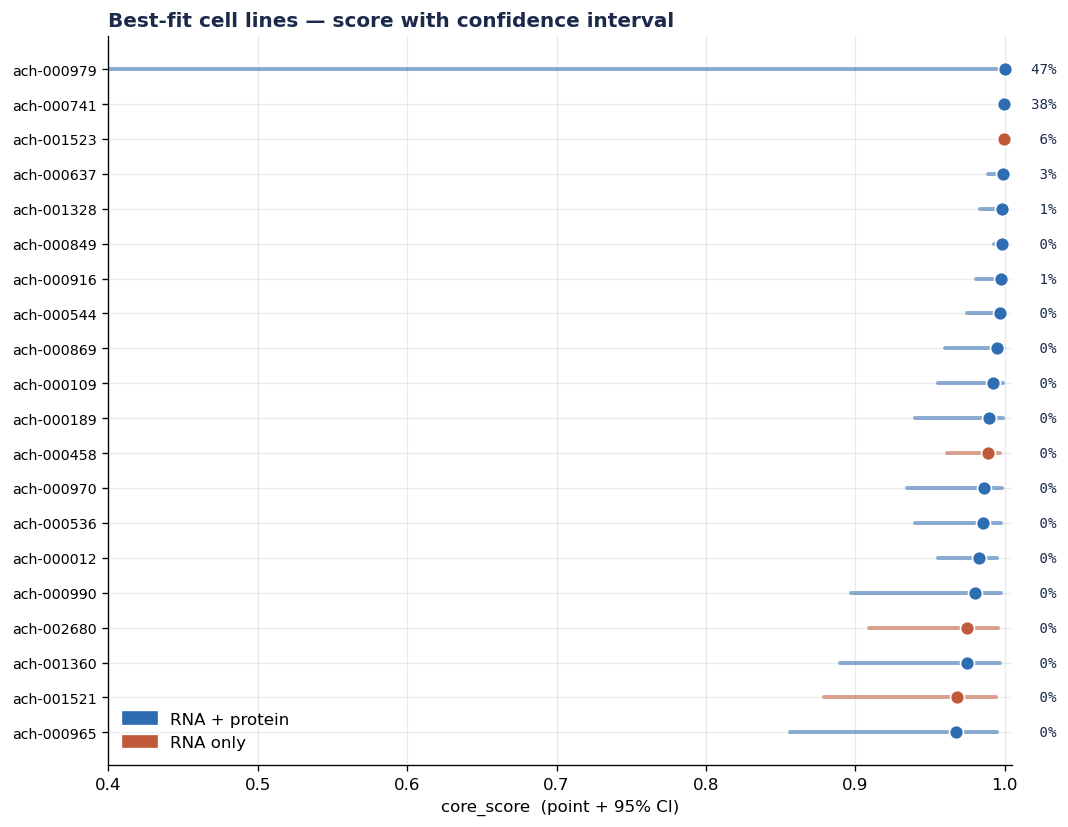

In [23]:
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":.25,"axes.axisbelow":True})
INK, C2, C1 = "#1b2a4a", "#2f6db3", "#c05a3a"
top = res.head(20).iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9,7))
for i, r in top.iterrows():
    col = C2 if r.n_layers==2 else C1
    ax.plot([r.ci_lo, r.ci_hi],[i,i], color=col, lw=2.4, alpha=.55, solid_capstyle="round")
    ax.scatter(r.core_score, i, color=col, s=70, zorder=3, edgecolor="white", lw=1)
    ax.text(1.006, i, f"{r.top1_winrate:4.0f}%", va="center", ha="left", fontsize=8.5, family="monospace", color=INK)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.model_id, fontsize=8.5)
ax.set_xlabel("core_score  (point + 95% CI)"); ax.set_xlim(0.4, 1.005)
ax.set_title("Best-fit cell lines — score with confidence interval", fontweight="bold", color=INK, loc="left")
ax.legend(handles=[Patch(color=C2,label="RNA + protein"),Patch(color=C1,label="RNA only")],
          loc="lower left", frameon=False); plt.tight_layout(); plt.show()

**Figure 2 — same uncertainty, two rankings** (global vs within-tissue stability).

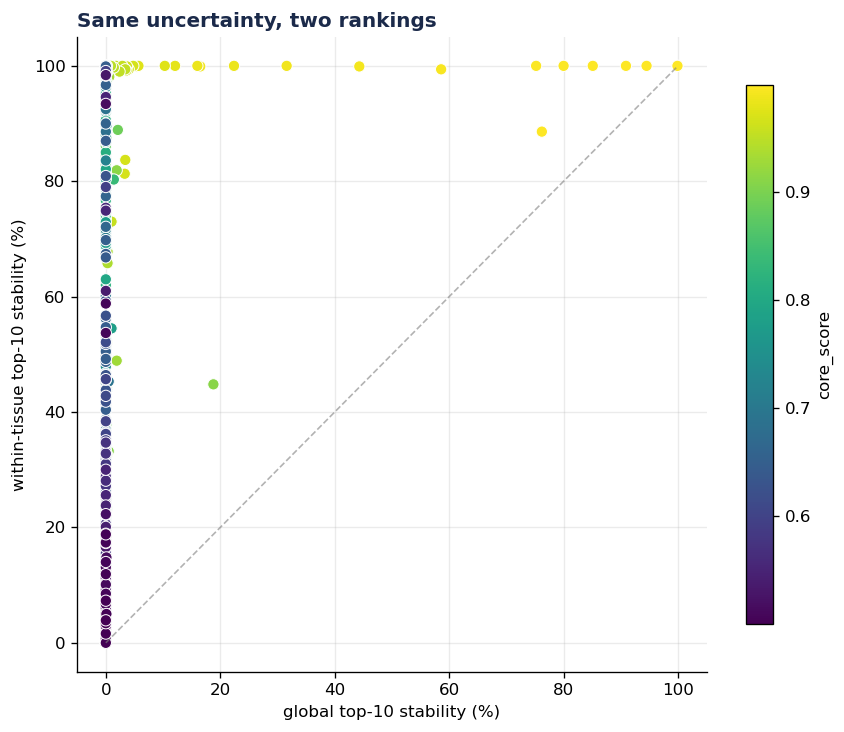

In [24]:
d = res[res.core_score > 0.5]
fig, ax = plt.subplots(figsize=(7.4,6.2))
sc = ax.scatter(d.topk_global_pct, d.topk_lineage_pct, c=d.core_score, cmap="viridis",
                s=46, edgecolor="white", lw=.6)
ax.plot([0,100],[0,100],"--",color="gray",lw=1,alpha=.6)
ax.set_xlabel("global top-10 stability (%)"); ax.set_ylabel("within-tissue top-10 stability (%)")
ax.set_title("Same uncertainty, two rankings", fontweight="bold", color=INK, loc="left")
fig.colorbar(sc, label="core_score", shrink=.85); plt.tight_layout(); plt.show()

**Figure 3 — the uncertainty is data-driven** (CI width vs RNA source coverage).

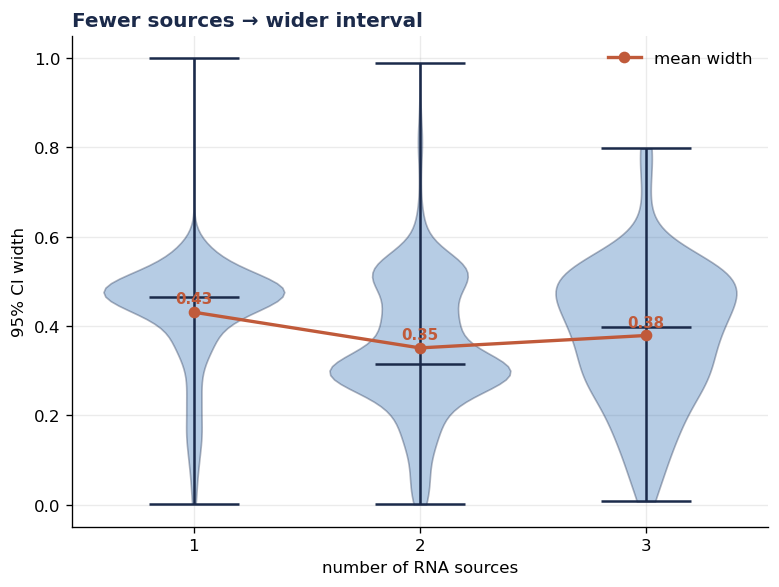

In [41]:
fig, ax = plt.subplots(figsize=(6.6,5.0))
groups = [res[res.n_sources==kk].ci_width.values for kk in (1,2,3)]; groups=[x for x in groups if len(x)]
parts = ax.violinplot(groups, positions=range(1,len(groups)+1), showmedians=True, widths=.8)
for b in parts["bodies"]: b.set_facecolor(C2); b.set_alpha(.35); b.set_edgecolor(INK)
for key in ("cmedians","cbars","cmins","cmaxes"): parts[key].set_color(INK)
means=[x.mean() for x in groups]; ax.plot(range(1,len(groups)+1), means, "o-", color=C1, lw=2, label="mean width")
for x,mu in zip(range(1,len(groups)+1),means): ax.text(x,mu+.02,f"{mu:.2f}",ha="center",color=C1,fontweight="bold",fontsize=9)
ax.set_xticks(range(1,len(groups)+1)); ax.set_xlabel("number of RNA sources"); ax.set_ylabel("95% CI width")
ax.set_title("Fewer sources → wider interval", fontweight="bold", color=INK, loc="left")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Figure 4 — what the interval is** (score distribution for a confident vs contested line).

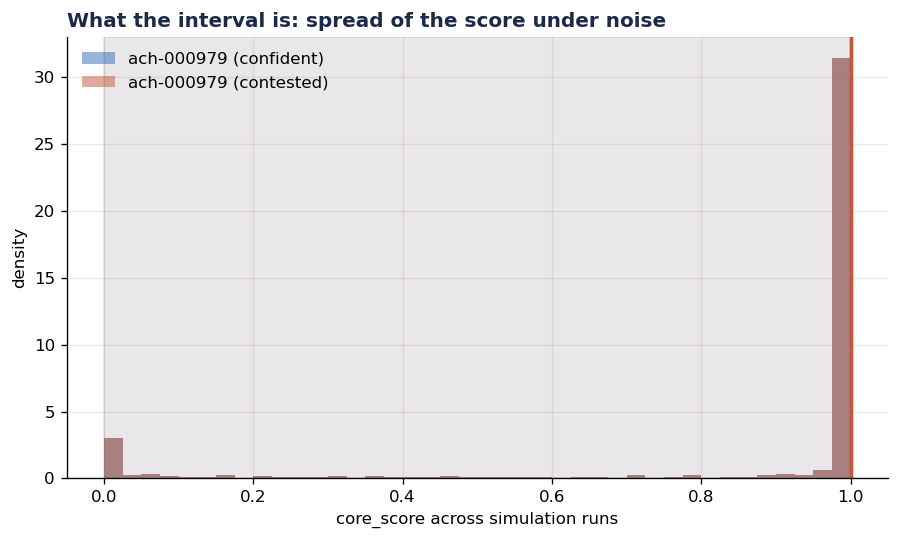

In [26]:
confident = res.iloc[0].model_id
contested = res.iloc[(res.ci_width*(res.core_score>.6)).values.argmax()].model_id
fig, ax = plt.subplots(figsize=(7.6,4.6))
for mid,col,lab in [(confident,C2,"confident"),(contested,C1,"contested")]:
    s = scores[:, id_ix[mid]]
    ax.hist(s, bins=40, color=col, alpha=.5, density=True, label=f"{mid} ({lab})")
    r = res.set_index("model_id").loc[mid]
    ax.axvline(r.core_score, color=col, lw=2); ax.axvspan(r.ci_lo, r.ci_hi, color=col, alpha=.08)
ax.set_xlabel("core_score across simulation runs"); ax.set_ylabel("density")
ax.set_title("What the interval is: spread of the score under noise", fontweight="bold", color=INK, loc="left")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

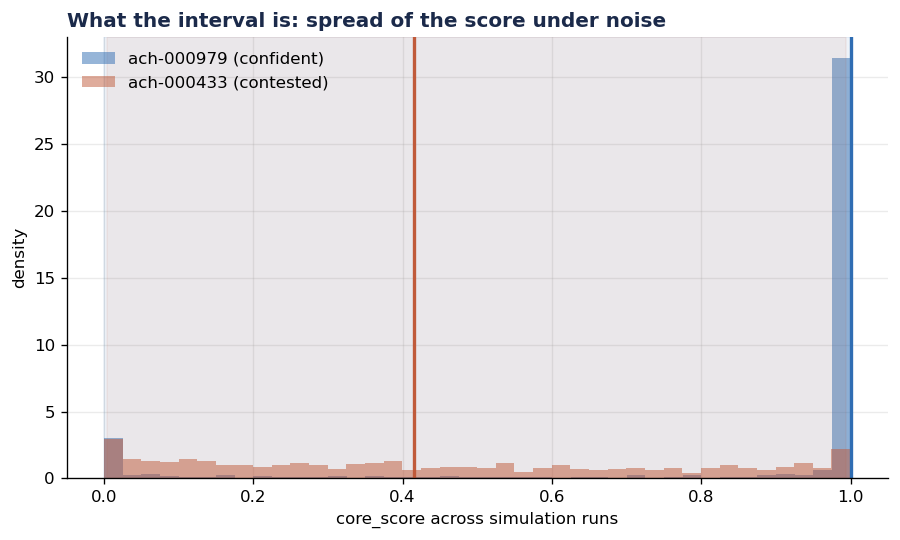

confident: ach-000979 | contested: ach-000433


In [40]:
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":.25,
                     "axes.axisbelow":True,"axes.facecolor":"white","figure.facecolor":"white"})
INK, C2, C1 = "#1b2a4a", "#2f6db3", "#c05a3a"

confident = res.iloc[0].model_id
# contested = widest interval among lines that are NOT the confident one and not saturated
cand = res[(res.model_id != confident) & (res.core_score < 0.97)].copy()
contested = cand.sort_values("ci_width", ascending=False).iloc[0].model_id
assert contested != confident, "picker still returned the confident line"

fig, ax = plt.subplots(figsize=(7.6,4.6))
for mid, col, lab in [(confident, C2, "confident"), (contested, C1, "contested")]:
    s = scores[:, id_ix[mid]]
    ax.hist(s, bins=40, color=col, alpha=.5, density=True, label=f"{mid} ({lab})")
    r = res.set_index("model_id").loc[mid]
    ax.axvline(r.core_score, color=col, lw=2); ax.axvspan(r.ci_lo, r.ci_hi, color=col, alpha=.08)
ax.set_xlabel("core_score across simulation runs"); ax.set_ylabel("density")
ax.set_title("What the interval is: spread of the score under noise", fontweight="bold", color=INK, loc="left")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

print("confident:", confident, "| contested:", contested)   # confirm two different real ach-000xxx IDs

## Notes and caveats

- The interval is a **sensitivity / reproducibility** measure — how much a recommendation moves under
  measurement noise — **not** a calibrated probability that a line is biologically best.
- **Regime-3 is a bonus source of honesty here.** Membership depends on hard `|z|>1` and sign
  thresholds, so a line near those boundaries flips regime across draws, and the interval captures that
  extra uncertainty automatically.
- Several *scoring* constants (`SD_SHRINK_N0`, `PROT_RESID_N0`, the ±5 winsor bounds) are flagged
  "first-pass / unvalidated" in `core_score.py`. That doesn't affect the CI's validity — we quantify
  stability around whatever the pipeline computes — but it strengthens the case for reporting that the
  *ordering* of the stability numbers is robust to reasonable moves in both the scoring knobs and the
  noise knobs.
- The recompute must match the stored score (centre-draw check). If it drifts, the first suspects are
  the three `ci_globals.json` scalars being stale, or a constant out of sync with `core_score.py`.

# Additional tests

## CI-overlap rank-swap check (validates the core ranking claim)

In [27]:
def overlap_swap_check(con, genes, N=1000, k=10):
    """For pairs with disjoint 95% CIs, how often do they swap order across draws?
    A calibrated interval => disjoint-CI pairs almost never swap (target ~<5%)."""
    rows = []
    for gid in genes:
        res, scores, ids = run_gene_ci(con, gid, N=N, k=k)
        s = scores  # (N, n_lines), columns aligned to ids
        cs = res.set_index("model_id").loc[ids, ["core_score","ci_lo","ci_hi"]].to_numpy()
        lo, hi = cs[:,1], cs[:,2]
        n = len(ids)
        # restrict to the competitive set (top ~30 by score) to keep pairs meaningful
        order = np.argsort(-cs[:,0])[:30]
        disjoint = 0; swaps = 0
        for a_i in range(len(order)):
            for b_i in range(a_i+1, len(order)):
                a, b = order[a_i], order[b_i]
                if hi[a] < lo[b] or hi[b] < lo[a]:          # CIs disjoint
                    disjoint += 1
                    # centre order: a should beat b (a has higher score since order desc)
                    higher, lower = (a, b) if cs[a,0] >= cs[b,0] else (b, a)
                    swap_frac = np.mean(scores[:, lower] > scores[:, higher])
                    swaps += swap_frac
        if disjoint:
            rows.append({"gene": gid, "disjoint_pairs": disjoint,
                         "mean_swap_rate": swaps/disjoint})
    df = pd.DataFrame(rows)
    print(f"genes with disjoint-CI pairs: {len(df)}")
    print(f"mean swap rate among disjoint-CI pairs: {df.mean_swap_rate.mean():.3%}")
    print(f"  (calibrated intervals => this is small; >>5% means intervals too narrow)")
    return df

## ±50% knob sweep (backs the robustness claim already in your Methods)

In [28]:
def knob_sweep(con, genes, N=500, k=10):
    """Re-run with each noise knob x0.5 and x1.5; check win-rate ranking stability
    (Spearman) vs baseline. Stable ranking => conclusions don't hinge on knob values."""
    import copy
    knobs = ["RNA_BASE_FLOOR", "PROT_BASE", "RNA_TAU_PRIOR"]
    g = globals()
    baseline_vals = {kk: g[kk] for kk in knobs}

    def _winrates(gid):
        r, _, _ = run_gene_ci(con, gid, N=N, k=k)
        return r.set_index("model_id")["top1_winrate"]

    out = []
    for gid in genes:
        base = _winrates(gid)
        for kk in knobs:
            for factor in (0.5, 1.5):
                g[kk] = baseline_vals[kk] * factor      # perturb one knob
                try:
                    alt = _winrates(gid).reindex(base.index)
                    rho = base.corr(alt, method="spearman")
                    out.append({"gene": gid, "knob": kk, "factor": factor, "spearman": rho})
                finally:
                    g[kk] = baseline_vals[kk]            # restore immediately
    df = pd.DataFrame(out)
    print("win-rate ranking stability (Spearman) under ±50% knob moves:")
    print(df.groupby(["knob","factor"])["spearman"].mean().round(3).to_string())
    print(f"\noverall mean Spearman: {df.spearman.mean():.3f}  (>~0.9 => robust)")
    return df

## Regime-3 flip count (tests the "elegant bonus" claim before you assert it)

In [29]:
def regime3_flip_check(con, genes, N=1000):
    """Fraction of two-layer lines whose regime-3 membership differs from the centre,
    at least once across draws. Tests whether regime-3 flipping adds real uncertainty."""
    import json
    from config import RNA_Z, PROT_Z, CORE_SCORE
    g_globals = json.loads((CORE_SCORE.parent/"ci_globals.json").read_text())
    rng = np.random.default_rng(42)
    rows = []
    for gid in genes:
        rz, pz, gid_u = _gene_leaves(con, gid)
        anchor = build_anchor(rz.rename(columns={"n_sources":"n_sources"}),
                              pz.rename(columns={"n_sources":"n_sources"}), g_globals)
        base = (rz.rename(columns={"n_sources":"n_sources_rna"})
                  .merge(pz.rename(columns={"n_sources":"n_sources_prot"}), on="model_id", how="left"))
        has_p = base.prot_z.notna().to_numpy()
        if has_p.sum() == 0:
            continue
        rna_mu = base.rna_z.to_numpy(); rna_sd = base.se_rna.to_numpy()
        prot_mu = base.prot_z.to_numpy(float); prot_sd = np.nan_to_num(base.se_prot.to_numpy(float))
        nsrc_r = base.n_sources_rna.to_numpy(float); nsrc_p = base.n_sources_prot.to_numpy(float)

        def _regime(rz_, pz_):
            rmed, rsd = _lookup(nsrc_r, anchor["rna_str"])
            rna_std = np.clip((rz_-rmed)/rsd, -RNA_WINSOR_BOUND, RNA_WINSOR_BOUND)
            pmed, psd = _lookup(np.where(has_p, nsrc_p, np.nan), anchor["protstd_str"])
            with np.errstate(invalid="ignore"):
                pstd = np.clip((pz_-pmed)/psd, -PROT_STD_WINSOR_BOUND, PROT_STD_WINSOR_BOUND)
                reg = ((np.abs(rna_std) > REGIME3_SIG_THRESH) & (np.abs(pstd) > REGIME3_SIG_THRESH)
                       & (np.sign(rna_std) != np.sign(pstd)) & np.isfinite(pstd))
            return reg & has_p

        centre_reg = _regime(rna_mu, prot_mu)
        n = len(base); ever_flipped = np.zeros(n, bool)
        for _ in range(N):
            rz_ = rna_mu + rng.normal(0,1,n)*rna_sd
            pz_ = prot_mu.copy(); pz_[has_p] = prot_mu[has_p] + rng.normal(0,1,int(has_p.sum()))*prot_sd[has_p]
            ever_flipped |= (_regime(rz_, pz_) != centre_reg)
        two = has_p
        rows.append({"gene": gid, "two_layer": int(two.sum()),
                     "centre_regime3": int(centre_reg.sum()),
                     "ever_flip_frac": float(ever_flipped[two].mean())})
    df = pd.DataFrame(rows)
    print(f"mean fraction of two-layer lines that flip regime at least once: "
          f"{df.ever_flip_frac.mean():.2%}")
    print(f"mean centre regime-3 lines/gene: {df.centre_regime3.mean():.1f}")
    return df

## Winsor-widening test (the deep one — is "saturation dominates" real or an artifact?)

In [30]:
def winsor_test(con, genes, N=300, bounds=(5.0, 10.0)):
    """Re-measure corr(width, |score-0.5|) vs corr(width, src_sd) at different winsor
    bounds. If saturation dominance shrinks when bounds widen, it's a clip/Phi artifact;
    if it persists, it reflects something real."""
    g = globals()
    orig = (RNA_WINSOR_BOUND, PROT_STD_WINSOR_BOUND, PROT_RESID_WINSOR_BOUND)
    rbs_all = pd.read_parquet(RNA_Z.parent/"bulk_rna_z_by_source.parquet")
    rbs_all["gene_id"] = rbs_all.gene_id.str.upper(); rbs_all["model_id"] = rbs_all.model_id.str.lower()
    rbs_all["src_sd"] = rbs_all[["z_depmap","z_hpa_rna","z_geo"]].std(axis=1, ddof=1)

    results = {}
    for B in bounds:
        g["RNA_WINSOR_BOUND"] = g["PROT_STD_WINSOR_BOUND"] = g["PROT_RESID_WINSOR_BOUND"] = B
        pool = []
        for gid in genes:
            r, _, _ = run_gene_ci(con, gid, N=N)
            r = r.assign(model_id=r.model_id.str.lower())
            rg = rbs_all[rbs_all.gene_id==_resolve_gid(con,gid).upper()][["model_id","src_sd"]]
            pool.append(r.merge(rg, on="model_id", how="left"))
        P = pd.concat(pool, ignore_index=True)
        P["dist"] = (P.core_score-0.5).abs()
        results[B] = {"corr_width_saturation": P.dist.corr(-P.ci_width),   # sign: near-mid=wide
                      "corr_width_srcsd": P[P.src_sd.notna()].ci_width.corr(P[P.src_sd.notna()].src_sd),
                      "mean_width": P.ci_width.mean()}
    (g["RNA_WINSOR_BOUND"], g["PROT_STD_WINSOR_BOUND"], g["PROT_RESID_WINSOR_BOUND"]) = orig
    print("winsor bound | corr(width, saturation) | corr(width, src_sd) | mean width")
    for B, v in results.items():
        print(f"  ±{B:<5} | {v['corr_width_saturation']:+.3f} | {v['corr_width_srcsd']:+.3f} | {v['mean_width']:.3f}")
    return results

In [31]:
core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core.ensg_id.str.upper()
rng = np.random.default_rng(0)
genes = list(rng.choice(core.ensg_id.unique(), 30, replace=False))

swap_df   = overlap_swap_check(con, genes, N=1000)
knob_df   = knob_sweep(con, genes, N=400)
regime_df = regime3_flip_check(con, genes, N=800)
winsor    = winsor_test(con, genes, N=300, bounds=(5.0, 10.0))

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


genes with disjoint-CI pairs: 19
mean swap rate among disjoint-CI pairs: 0.170%
  (calibrated intervals => this is small; >>5% means intervals too narrow)


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.

win-rate ranking stability (Spearman) under ±50% knob moves:
knob            factor
PROT_BASE       0.5       0.919
                1.5       0.891
RNA_BASE_FLOOR  0.5       0.891
                1.5       0.854
RNA_TAU_PRIOR   0.5       0.967
                1.5       0.950

overall mean Spearman: 0.912  (>~0.9 => robust)


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


mean fraction of two-layer lines that flip regime at least once: 66.59%
mean centre regime-3 lines/gene: 6.7


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


winsor bound | corr(width, saturation) | corr(width, src_sd) | mean width
  ±5.0   | +0.412 | +0.117 | 0.433
  ±10.0  | +0.411 | +0.117 | 0.433


## Rank-calibration coverage (the reportable version of the overlap test)

In [32]:
def rank_calibration(con, genes, N=1000, level=0.95):
    """Coverage-style: for disjoint-CI pairs, fraction whose centre order holds in
    >= `level` of draws. Calibrated => this fraction is ~`level` or higher."""
    rows = []
    for gid in genes:
        res, scores, ids = run_gene_ci(con, gid, N=N)
        cs = res.set_index("model_id").loc[ids, ["core_score","ci_lo","ci_hi"]].to_numpy()
        lo, hi, sc = cs[:,1], cs[:,2], cs[:,0]
        order = np.argsort(-sc)[:30]
        preserved = []
        for i in range(len(order)):
            for j in range(i+1, len(order)):
                a, b = order[i], order[j]
                if hi[a] < lo[b] or hi[b] < lo[a]:                 # disjoint CIs
                    hi_, lo_ = (a, b) if sc[a] >= sc[b] else (b, a)
                    hold = np.mean(scores[:, hi_] > scores[:, lo_])  # order preserved per draw
                    preserved.append(hold >= level)
        if preserved:
            rows.append({"gene": gid, "n_pairs": len(preserved),
                         "frac_order_preserved": np.mean(preserved)})
    df = pd.DataFrame(rows)
    tot = (df.n_pairs*df.frac_order_preserved).sum() / df.n_pairs.sum()
    print(f"disjoint-CI pairs across {len(df)} genes: {int(df.n_pairs.sum())}")
    print(f"pairs whose order holds in >={level:.0%} of draws: {tot:.1%}")
    print(f"  (nominal target: >= {level:.0%}. This is the rank-calibration statement.)")
    return df

## Self-consistency: centre vs draw-median, by score bin

In [33]:
def centre_median_consistency(con, genes, N=1000):
    """Per line: (draw median − centre). Systematic gap signals saturation skew.
    Report by score bin — the gap should grow near 0/1 where Phi compresses."""
    pool = []
    for gid in genes:
        res, scores, ids = run_gene_ci(con, gid, N=N)
        med = np.median(scores, axis=0)
        centre = res.set_index("model_id").loc[ids, "core_score"].to_numpy()
        pool.append(pd.DataFrame({"core_score": centre, "gap": med - centre}))
    P = pd.concat(pool, ignore_index=True)
    P["bin"] = pd.cut(P.core_score, [0,.2,.4,.6,.8,1.0])
    tab = P.groupby("bin", observed=True)["gap"].agg(["mean","std","count"]).round(4)
    print("draw-median minus stored centre, by score bin:")
    print(tab.to_string())
    print(f"\noverall mean |gap|: {P.gap.abs().mean():.4f}")
    print("  (near-zero mid-range, negative near 1.0 / positive near 0.0 => saturation skew)")
    return P

## Convergence (the missing "why N=1000" figure)

In [34]:
def convergence_check(con, gene, N_grid=(100,300,1000,3000,10000), k=10, seed=42):
    """Track a few lines' win-rate and CI bounds as N grows. Estimates should flatten."""
    rows = []
    for N in N_grid:
        res, _, _ = run_gene_ci(con, gene, N=N, k=k, seed=seed)
        top = res.head(5)
        for _, r in top.iterrows():
            rows.append({"N": N, "model_id": r.model_id, "top1_winrate": r.top1_winrate,
                         "ci_lo": r.ci_lo, "ci_hi": r.ci_hi, "ci_width": r.ci_width})
    df = pd.DataFrame(rows)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4.2))
    for mid, g in df.groupby("model_id"):
        a1.plot(g.N, g.top1_winrate, "o-", label=mid, alpha=.8)
        a2.plot(g.N, g.ci_width, "o-", alpha=.8)
    a1.set_xscale("log"); a2.set_xscale("log")
    a1.set_xlabel("N draws"); a1.set_ylabel("top-1 win-rate (%)"); a1.set_title("Win-rate vs N")
    a2.set_xlabel("N draws"); a2.set_ylabel("95% CI width"); a2.set_title("CI width vs N")
    a1.legend(fontsize=7, frameon=False); plt.tight_layout(); plt.show()
    # quantify: change in win-rate from N=1000 to N=10000
    piv = df.pivot_table(index="model_id", columns="N", values="top1_winrate")
    if 1000 in piv and 10000 in piv:
        print(f"mean |win-rate change| 1000→10000: {(piv[10000]-piv[1000]).abs().mean():.2f} pp")
    return df

## Variance decomposition (RNA vs protein vs interaction)

In [35]:
def variance_decomposition(con, gene, N=2000, seed=42):
    """Fraction of two-layer score variance from RNA alone, protein alone, interaction."""
    import json
    from config import CORE_SCORE
    g_globals = json.loads((CORE_SCORE.parent/"ci_globals.json").read_text())
    rz, pz, gid = _gene_leaves(con, gene)
    anchor = build_anchor(rz, pz, g_globals)
    base = (rz.rename(columns={"n_sources":"n_sources_rna"})
              .merge(pz.rename(columns={"n_sources":"n_sources_prot"}), on="model_id", how="left"))
    n = len(base); has_p = base.prot_z.notna().to_numpy()
    rna_mu, rna_sd = base.rna_z.to_numpy(), base.se_rna.to_numpy()
    prot_mu, prot_sd = base.prot_z.to_numpy(float), np.nan_to_num(base.se_prot.to_numpy(float))
    nsr, nsp = base.n_sources_rna.to_numpy(float), base.n_sources_prot.to_numpy(float)
    rng = np.random.default_rng(seed)

    def var_under(perturb_rna, perturb_prot):
        S = np.empty((N, n))
        for i in range(N):
            rz_ = rna_mu + (rng.normal(0,1,n)*rna_sd if perturb_rna else 0)
            pz_ = prot_mu.copy()
            if perturb_prot:
                pz_[has_p] = prot_mu[has_p] + rng.normal(0,1,int(has_p.sum()))*prot_sd[has_p]
            S[i] = core_score_chain(rz_, pz_, nsr, nsp, has_p, anchor)
        return S.var(axis=0)

    v_rna  = var_under(True,  False)
    v_prot = var_under(False, True)
    v_both = var_under(True,  True)
    v_inter = np.clip(v_both - v_rna - v_prot, 0, None)     # interaction (non-additivity)
    two = has_p
    tot = np.where(v_both[two] > 0, v_both[two], np.nan)
    print(f"two-layer lines: {int(two.sum())}")
    print(f"  mean share of score variance — RNA:  {np.nanmean(v_rna[two]/tot):.1%}")
    print(f"  mean share of score variance — Prot: {np.nanmean(v_prot[two]/tot):.1%}")
    print(f"  mean share of score variance — Inter:{np.nanmean(v_inter[two]/tot):.1%}")
    return {"v_rna": v_rna, "v_prot": v_prot, "v_both": v_both, "v_inter": v_inter, "has_p": has_p}

## Run

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


disjoint-CI pairs across 19 genes: 570
pairs whose order holds in >=95% of draws: 100.0%
  (nominal target: >= 95%. This is the rank-calibration statement.)


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2011877257.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw = stats.pearsonr(shared.prot_z.fillna(0), shared.rna_z.fillna(0))[0]
/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


draw-median minus stored centre, by score bin:
              mean     std  count
bin                              
(0.0, 0.2]  0.0027  0.0415   4276
(0.2, 0.4]  0.0011  0.0173   8648
(0.4, 0.6]  0.0002  0.0089  10961
(0.6, 0.8] -0.0016  0.0219   8111
(0.8, 1.0] -0.0045  0.0569   4229

overall mean |gap|: 0.0056
  (near-zero mid-range, negative near 1.0 / positive near 0.0 => saturation skew)


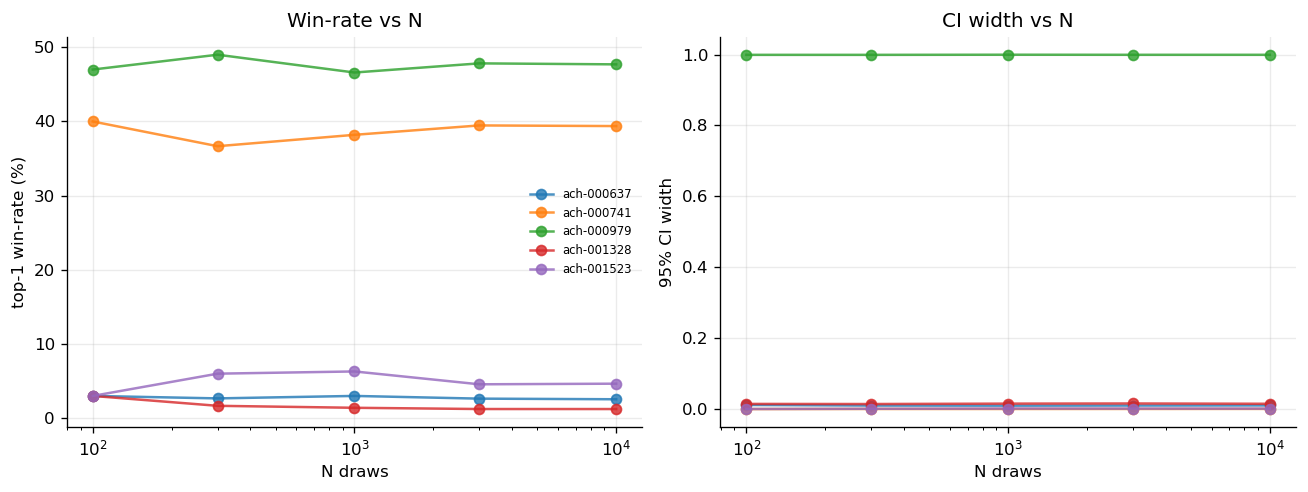

mean |win-rate change| 1000→10000: 0.91 pp
two-layer lines: 694
  mean share of score variance — RNA:  6.0%
  mean share of score variance — Prot: 94.6%
  mean share of score variance — Inter:2.3%


In [36]:
core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core.ensg_id.str.upper()
rng = np.random.default_rng(0)
genes = list(rng.choice(core.ensg_id.unique(), 30, replace=False))

cal_df  = rank_calibration(con, genes, N=1000)
gap_df  = centre_median_consistency(con, genes, N=1000)
conv_df = convergence_check(con, "EGFR")                 # single gene, the figure
vd      = variance_decomposition(con, "EGFR", N=2000)    # single gene

In [37]:
shares = []
for gid in genes:
    try:
        vd = variance_decomposition(con, gid, N=800)
        two = vd["has_p"]; tot = vd["v_both"][two]
        ok = tot > 0
        shares.append({"gene": gid,
                       "rna":  np.nanmean(vd["v_rna"][two][ok]/tot[ok]),
                       "prot": np.nanmean(vd["v_prot"][two][ok]/tot[ok])})
    except Exception: pass
sh = pd.DataFrame(shares)
print(sh[["rna","prot"]].describe().round(3))

two-layer lines: 0
  mean share of score variance — RNA:  nan%
  mean share of score variance — Prot: nan%
  mean share of score variance — Inter:nan%


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:33: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — RNA:  {np.nanmean(v_rna[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:34: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Prot: {np.nanmean(v_prot[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:35: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Inter:{np.nanmean(v_inter[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:8: RuntimeWarning: Mean of empty slice
  "rna":  np.nanmean(vd["v_rna"][two][ok]/tot[ok]),
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:9: RuntimeWarning: Mean of empty slice
  "prot": np.nanmean(vd["v_prot"][two][ok]/tot[ok])})


two-layer lines: 821
  mean share of score variance — RNA:  7.0%
  mean share of score variance — Prot: 93.1%
  mean share of score variance — Inter:3.6%
two-layer lines: 0
  mean share of score variance — RNA:  nan%
  mean share of score variance — Prot: nan%
  mean share of score variance — Inter:nan%


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:33: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — RNA:  {np.nanmean(v_rna[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:34: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Prot: {np.nanmean(v_prot[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:35: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Inter:{np.nanmean(v_inter[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:8: RuntimeWarning: Mean of empty slice
  "rna":  np.nanmean(vd["v_rna"][two][ok]/tot[ok]),
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:9: RuntimeWarning: Mean of empty slice
  "prot": np.nanmean(vd["v_prot"][two][ok]/tot[ok])})


two-layer lines: 18
  mean share of score variance — RNA:  3.2%
  mean share of score variance — Prot: 93.3%
  mean share of score variance — Inter:6.6%
two-layer lines: 821
  mean share of score variance — RNA:  13.3%
  mean share of score variance — Prot: 87.6%
  mean share of score variance — Inter:3.6%
two-layer lines: 375
  mean share of score variance — RNA:  6.9%
  mean share of score variance — Prot: 95.1%
  mean share of score variance — Inter:2.8%
two-layer lines: 821
  mean share of score variance — RNA:  13.9%
  mean share of score variance — Prot: 88.8%
  mean share of score variance — Inter:3.7%
two-layer lines: 375
  mean share of score variance — RNA:  5.0%
  mean share of score variance — Prot: 96.8%
  mean share of score variance — Inter:2.7%
two-layer lines: 375
  mean share of score variance — RNA:  11.1%
  mean share of score variance — Prot: 92.0%
  mean share of score variance — Inter:2.4%
two-layer lines: 821
  mean share of score variance — RNA:  10.1%
  mean s

...

two-layer lines: 821
  mean share of score variance — RNA:  10.1%
  mean share of score variance — Prot: 88.1%
  mean share of score variance — Inter:7.6%
two-layer lines: 821
  mean share of score variance — RNA:  6.1%
  mean share of score variance — Prot: 95.7%
  mean share of score variance — Inter:3.4%
two-layer lines: 820
  mean share of score variance — RNA:  11.7%
  mean share of score variance — Prot: 89.1%
  mean share of score variance — Inter:3.3%
two-layer lines: 0
  mean share of score variance — RNA:  nan%
  mean share of score variance — Prot: nan%
  mean share of score variance — Inter:nan%


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:33: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — RNA:  {np.nanmean(v_rna[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:34: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Prot: {np.nanmean(v_prot[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:35: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Inter:{np.nanmean(v_inter[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:8: RuntimeWarning: Mean of empty slice
  "rna":  np.nanmean(vd["v_rna"][two][ok]/tot[ok]),
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:9: RuntimeWarning: Mean of empty slice
  "prot": np.nanmean(vd["v_prot"][two][ok]/tot[ok])})


two-layer lines: 821
  mean share of score variance — RNA:  5.9%
  mean share of score variance — Prot: 95.0%
  mean share of score variance — Inter:4.9%
two-layer lines: 0
  mean share of score variance — RNA:  nan%
  mean share of score variance — Prot: nan%
  mean share of score variance — Inter:nan%


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:33: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — RNA:  {np.nanmean(v_rna[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:34: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Prot: {np.nanmean(v_prot[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/658221795.py:35: RuntimeWarning: Mean of empty slice
  print(f"  mean share of score variance — Inter:{np.nanmean(v_inter[two]/tot):.1%}")
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:8: RuntimeWarning: Mean of empty slice
  "rna":  np.nanmean(vd["v_rna"][two][ok]/tot[ok]),
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_59622/2504689593.py:9: RuntimeWarning: Mean of empty slice
  "prot": np.nanmean(vd["v_prot"][two][ok]/tot[ok])})


two-layer lines: 821
  mean share of score variance — RNA:  19.8%
  mean share of score variance — Prot: 80.5%
  mean share of score variance — Inter:3.7%
two-layer lines: 812
  mean share of score variance — RNA:  7.7%
  mean share of score variance — Prot: 92.9%
  mean share of score variance — Inter:3.6%
two-layer lines: 821
  mean share of score variance — RNA:  10.0%
  mean share of score variance — Prot: 90.0%
  mean share of score variance — Inter:6.2%
two-layer lines: 211
  mean share of score variance — RNA:  10.9%
  mean share of score variance — Prot: 92.0%
  mean share of score variance — Inter:3.4%
          rna    prot
count  19.000  19.000
mean    0.093   0.917
std     0.044   0.046
min     0.032   0.805
25%     0.060   0.889
50%     0.100   0.920
75%     0.114   0.950
max     0.198   1.008


# CI extras

## Regime-switch rate

In [38]:
def _regime_membership(rna_z, prot_z, nsrc_rna, nsrc_prot, has_p, a):
    rmed, rsd = _lookup(nsrc_rna, a["rna_str"])
    rna_std = np.clip((rna_z - rmed)/rsd, -RNA_WINSOR_BOUND, RNA_WINSOR_BOUND)
    reg = np.zeros(len(rna_z), bool)
    if has_p.any():
        pmed, psd = _lookup(np.where(has_p, nsrc_prot, np.nan), a["protstd_str"])
        with np.errstate(invalid="ignore"):
            pstd = np.clip((prot_z - pmed)/psd, -PROT_STD_WINSOR_BOUND, PROT_STD_WINSOR_BOUND)
            reg = ((np.abs(rna_std) > REGIME3_SIG_THRESH) & (np.abs(pstd) > REGIME3_SIG_THRESH)
                   & (np.sign(rna_std) != np.sign(pstd)) & np.isfinite(pstd) & has_p)
    return reg


def monte_carlo_ci_ext(base, anchor, N=1000, k=10, seed=42, ci=0.95, rho_err=0.0):
    """Extends monte_carlo_ci with a per-line regime_switch_rate and an optional
    RNA/protein error correlation rho_err (0 = independent, the default)."""
    rng = np.random.default_rng(seed)
    ids = base.model_id.to_numpy(); n = len(base); lineage = base.lineage.to_numpy()
    rna_mu, rna_sd = base.rna_z.to_numpy(), base.se_rna.to_numpy()
    nsrc_rna = base.n_sources_rna.to_numpy(float)
    has_p = base.prot_z.notna().to_numpy()
    prot_mu = base.prot_z.to_numpy(float); prot_sd = np.nan_to_num(base.se_prot.to_numpy(float))
    nsrc_prot = base.n_sources_prot.to_numpy(float)
    a = anchor
    score  = lambda rz, pz: core_score_chain(rz, pz, nsrc_rna, nsrc_prot, has_p, a)
    regime = lambda rz, pz: _regime_membership(rz, pz, nsrc_rna, nsrc_prot, has_p, a)

    centre = score(rna_mu, prot_mu); centre_reg = regime(rna_mu, prot_mu)
    scores = np.empty((N, n)); top_g = np.zeros(n); top_l = np.zeros(n); win1 = np.zeros(n); switch = np.zeros(n)
    for i in range(N):
        e_rna = rng.normal(0, 1, n); e_ind = rng.normal(0, 1, n)
        e_prot = rho_err*e_rna + np.sqrt(max(1-rho_err**2, 0.0))*e_ind      # correlated protein error
        rz = rna_mu + e_rna*rna_sd
        pz = prot_mu.copy(); pz[has_p] = prot_mu[has_p] + e_prot[has_p]*prot_sd[has_p]
        s = score(rz, pz); scores[i] = s
        switch += (regime(rz, pz) != centre_reg)
        o = np.argsort(-s); top_g[o[:k]] += 1; win1[o[0]] += 1
        t = pd.DataFrame({"s": s, "lin": lineage})
        t["r"] = t.groupby("lin")["s"].rank(ascending=False, method="first")
        top_l[(t["r"] <= k).to_numpy()] += 1
    lo, hi = (1-ci)/2, 1-(1-ci)/2
    out = pd.DataFrame({"model_id": ids, "lineage": lineage, "core_score": centre,
        "ci_lo": np.quantile(scores, lo, axis=0), "ci_hi": np.quantile(scores, hi, axis=0),
        "topk_global_pct": 100*top_g/N, "topk_lineage_pct": 100*top_l/N, "top1_winrate": 100*win1/N,
        "regime_switch_rate": 100*switch/N,
        "n_layers": np.where(has_p, 2, 1), "n_sources": base.n_sources_rna.to_numpy()})
    out["ci_lo"] = np.minimum(out.ci_lo, out.core_score); out["ci_hi"] = np.maximum(out.ci_hi, out.core_score)
    out["ci_width"] = out.ci_hi - out.ci_lo
    return out.sort_values("core_score", ascending=False).reset_index(drop=True), scores, ids


def _base_anchor(con, gene):
    """Build the (base, anchor) a gene needs — same wiring as run_gene_ci."""
    import json
    from config import CORE_SCORE
    import common as C
    rz, pz, gid = _gene_leaves(con, gene)
    g_globals = json.loads((CORE_SCORE.parent/"ci_globals.json").read_text())
    anchor = build_anchor(rz, pz, g_globals)
    lm = C.load_lineage(con); lm.index = lm.index.str.lower()
    base = (rz.rename(columns={"n_sources":"n_sources_rna"})
              .merge(pz.rename(columns={"n_sources":"n_sources_prot"}), on="model_id", how="left"))
    base["lineage"] = base.model_id.map(lm)
    return base, anchor


# --- run on EGFR ---
base, anchor = _base_anchor(con, "EGFR")
res_r, _, _ = monte_carlo_ci_ext(base, anchor, N=1000)
two = res_r[res_r.n_layers == 2]
print(f"regime-switch rate (two-layer lines): mean {two.regime_switch_rate.mean():.1f}% | "
      f">10% switch: {(two.regime_switch_rate>10).mean():.0%} of two-layer lines")
res_r.head(12)[["model_id","core_score","ci_lo","ci_hi","top1_winrate","regime_switch_rate","n_layers"]].round(2)

regime-switch rate (two-layer lines): mean 0.7% | >10% switch: 2% of two-layer lines


,model_id,core_score,ci_lo,ci_hi,top1_winrate,regime_switch_rate,n_layers
0,ach-000979,1.00,0.00,1.0,46.3,2.6,2
1,ach-000741,1.00,1.00,1.0,42.3,0.0,2
2,ach-001523,1.00,1.00,1.0,4.9,0.0,1
3,ach-000637,1.00,0.99,1.0,2.3,0.0,2
4,ach-001328,1.00,0.98,1.0,1.1,0.0,2
5,ach-000849,1.00,0.99,1.0,0.4,0.0,2
6,ach-000916,1.00,0.98,1.0,0.8,0.0,2
7,ach-000544,1.00,0.98,1.0,0.3,0.0,2
8,ach-000869,0.99,0.96,1.0,0.2,0.0,2
9,ach-000109,0.99,0.96,1.0,0.0,0.0,2


In [39]:
res_r.tail()

,model_id,lineage,core_score,ci_lo,ci_hi,topk_global_pct,topk_lineage_pct,top1_winrate,regime_switch_rate,n_layers,n_sources,ci_width
1331,ach-000375,kidney,6.225812e-04,1.927633e-05,0.009139,0.0,0.0,0.0,0.0,2,2,0.009120
1332,ach-000202,colorectal,5.113788e-04,2.752002e-05,0.005938,0.0,0.0,0.0,0.0,2,2,0.005910
1333,ach-000347,pancreas,3.362309e-04,1.927602e-06,0.056803,0.0,0.0,0.0,0.0,2,2,0.056801
1334,ach-001368,esophagus,2.112854e-04,6.499051e-06,0.003126,0.0,0.0,0.0,0.0,2,1,0.003119
1335,ach-000096,kidney,6.355481e-09,9.657803e-10,0.000571,0.0,0.0,0.0,0.0,2,2,0.000571
